In [1]:
import pandas as pd

# ruta = "C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/biovars_espeletia_total.csv"
ruta = "C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/Espeletia_NASADEM_filt.csv"
bio = pd.read_csv(ruta, sep=",", encoding="utf-8")

In [2]:
# bio = bio.drop(columns=['system:index'])
bio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22309 entries, 0 to 22308
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   countryCode    22309 non-null  object 
 1   elevation_DEM  22309 non-null  int64  
 2   eventDate      22162 non-null  object 
 3   genus          22309 non-null  object 
 4   lat            22309 non-null  float64
 5   locality       20453 non-null  object 
 6   lon            22309 non-null  float64
 7   species        21146 non-null  object 
 8   stateProvince  21312 non-null  object 
 9   .geo           22309 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 1.7+ MB


In [3]:
bio.columns

Index(['countryCode', 'elevation_DEM', 'eventDate', 'genus', 'lat', 'locality',
       'lon', 'species', 'stateProvince', '.geo'],
      dtype='object')

In [4]:
print(bio.countryCode.unique())
# Ahora vamos a dejra solo las de CO
bio_col = bio[bio.countryCode == "CO"].copy()
print(bio_col.countryCode.unique())
bio_col.shape

['EC' 'CO' 'VE']
['CO']


(20220, 10)

In [5]:
# Codificar la columna 'species' como tipo cadena
bio_col['species'] = bio_col['species'].astype(str)

In [18]:
# Necesitamos filtrar solo las especies mas dominantes
# Leer el archivo .txt
with open('../data/primeras_especies.txt', 'r') as file:
    especies = file.read().splitlines()

print(especies)

['Espeletia grandiflora', 'Espeletia pycnophylla', 'Espeletia hartwegiana', 'Espeletia cleefii', 'Espeletia curialensis', 'nan', 'Espeletia corymbosa', 'Espeletia argentea', 'Espeletia boyacensis', 'Espeletia frontinoensis', 'Espeletia glandulosa', 'Espeletia praefrontina', 'Espeletia killipii', 'Espeletia murilloi', 'Espeletia brachyaxiantha', 'Espeletia uribei', 'Espeletia schultzii', 'Espeletia barclayana', 'Espeletia timotensis', 'Espeletia congestiflora', 'Espeletia petiolata', 'Espeletia tunjana', 'Espeletia lopezii', 'Espeletia muiska', 'Espeletia santanderensis', 'Espeletia moritziana']


In [19]:
print(type(especies))
especies
# Mirar nombres duplicados

<class 'list'>


['Espeletia grandiflora',
 'Espeletia pycnophylla',
 'Espeletia hartwegiana',
 'Espeletia cleefii',
 'Espeletia curialensis',
 'nan',
 'Espeletia corymbosa',
 'Espeletia argentea',
 'Espeletia boyacensis',
 'Espeletia frontinoensis',
 'Espeletia glandulosa',
 'Espeletia praefrontina',
 'Espeletia killipii',
 'Espeletia murilloi',
 'Espeletia brachyaxiantha',
 'Espeletia uribei',
 'Espeletia schultzii',
 'Espeletia barclayana',
 'Espeletia timotensis',
 'Espeletia congestiflora',
 'Espeletia petiolata',
 'Espeletia tunjana',
 'Espeletia lopezii',
 'Espeletia muiska',
 'Espeletia santanderensis',
 'Espeletia moritziana']

In [6]:
len(list(set(especies)))

NameError: name 'especies' is not defined

In [7]:
# Filtrar el DataFrame bio para que solo contenga las especies de la lista 'especies'
#bio_filt = bio_col[bio_col['species'].isin(especies)]
bio_filt = bio_col.copy()
# Mostrar el DataFrame filtrado
bio_filt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20220 entries, 2 to 22304
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   countryCode    20220 non-null  object 
 1   elevation_DEM  20220 non-null  int64  
 2   eventDate      20097 non-null  object 
 3   genus          20220 non-null  object 
 4   lat            20220 non-null  float64
 5   locality       18625 non-null  object 
 6   lon            20220 non-null  float64
 7   species        20220 non-null  object 
 8   stateProvince  19370 non-null  object 
 9   .geo           20220 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 1.7+ MB


In [9]:
len(bio_filt.species.unique())

88

In [8]:
print(bio_filt.isna().sum())

countryCode         0
elevation_DEM       0
eventDate         123
genus               0
lat                 0
locality         1595
lon                 0
species             0
stateProvince     850
.geo                0
dtype: int64


In [10]:
# Removemos otras fila innecesarias
bio_filt = bio_filt.drop(columns=['eventDate','locality','stateProvince'])
print(bio_filt.isna().sum())
print(bio_filt.shape)

countryCode      0
elevation_DEM    0
genus            0
lat              0
lon              0
species          0
.geo             0
dtype: int64
(20220, 7)


In [11]:
len(bio_filt.species.unique())

88

## Bioclimatic variables

Bioclimatic variables are derived from the monthly temperature and rainfall values in order to generate more biologically meaningful variables. These are often used in species distribution modeling and related ecological modeling techniques. The bioclimatic variables represent annual trends (e.g., mean annual temperature, annual precipitation) seasonality (e.g., annual range in temperature and precipitation) and extreme or limiting environmental factors (e.g., temperature of the coldest and warmest month, and precipitation of the wet and dry quarters). A quarter is a period of three months (1/4 of the year).

### They are coded as follows:

BIO1 = Annual Mean Temperature

BIO2 = Mean Diurnal Range (Mean of monthly (max temp - min temp))

BIO3 = Isothermality (BIO2/BIO7) (×100)

BIO4 = Temperature Seasonality (standard deviation ×100)

BIO5 = Max Temperature of Warmest Month

BIO6 = Min Temperature of Coldest Month

BIO7 = Temperature Annual Range (BIO5-BIO6)

BIO8 = Mean Temperature of Wettest Quarter

BIO9 = Mean Temperature of Driest Quarter

BIO10 = Mean Temperature of Warmest Quarter

BIO11 = Mean Temperature of Coldest Quarter

BIO12 = Annual Precipitation

BIO13 = Precipitation of Wettest Month

BIO14 = Precipitation of Driest Month

BIO15 = Precipitation Seasonality (Coefficient of Variation)

BIO16 = Precipitation of Wettest Quarter

BIO17 = Precipitation of Driest Quarter

BIO18 = Precipitation of Warmest Quarter

BIO19 = Precipitation of Coldest Quarter

Sin embargo, las unidades de estas biovariables pueden ser confusas. Para ellos la siguiente tabla:

| Código | Variable                                    | Unidad     | Notas clave                                    |
| ------ | ------------------------------------------- | ---------- | ---------------------------------------------- |
| bio1   | Temperatura media anual                     | **°C ×10** | Divide entre 10 para obtener °C reales         |
| bio2   | Rango diurno medio (temp. max - min diaria) | **°C ×10** |                                                |
| bio3   | Isotermalidad (bio2 / bio7) × 100           | **%**      |                                                |
| bio4   | Rango de temperatura anual (bio5 - bio6)    | **°C ×10** |                                                |
| bio5   | Temp. máxima del mes más cálido             | **°C ×10** |                                                |
| bio6   | Temp. mínima del mes más frío               | **°C ×10** |                                                |
| bio7   | Amplitud térmica anual (bio5 - bio6)        | **°C ×10** |                                                |
| bio8   | Temp. media del trimestre más húmedo        | **°C ×10** |                                                |
| bio9   | Temp. media del trimestre más seco          | **°C ×10** |                                                |
| bio10  | Temp. media del trimestre más cálido        | **°C ×10** |                                                |
| bio11  | Temp. media del trimestre más frío          | **°C ×10** |                                                |
| bio12  | Precipitación anual                         | **mm**     |                                                |
| bio13  | Precipitación del mes más húmedo            | **mm**     |                                                |
| bio14  | Precipitación del mes más seco              | **mm**     |                                                |
| bio15  | Estacionalidad de la precipitación (CV)     | **%**      | Es el coeficiente de variación (SD/mean × 100) |
| bio16  | Prec. del trimestre más húmedo              | **mm**     |                                                |
| bio17  | Prec. del trimestre más seco                | **mm**     |                                                |
| bio18  | Prec. del trimestre más cálido              | **mm**     |                                                |
| bio19  | Prec. del trimestre más frío                | **mm**     |                                                |


## Extraer la infrmación de las imagenes de Worldclim


In [6]:
# Listar los archivos .tif de la carpeta
import glob
import os

images = []
for file in glob.glob("C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images/*.tif"):
    # images.append(os.path.basename(file)) # Solo el archivo
    images.append(file) # Ruta completa - Necesario para que se encuentren los archivos

In [7]:
images

['C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images\\wc2.1_30s_bio_1.tif',
 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images\\wc2.1_30s_bio_10.tif',
 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images\\wc2.1_30s_bio_11.tif',
 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images\\wc2.1_30s_bio_12.tif',
 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images\\wc2.1_30s_bio_13.tif',
 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images\\wc2.1_30s_bio_14.tif',
 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images\\wc2.1_30s_bio_15.tif',
 'C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images\\wc2.1_30s_bio_16.tif',
 'C:/Users/danie/Document

In [14]:
# Convertir las base de datos a GeoDataFrame para reproyectar
import geopandas as gpd

gdf = gpd.GeoDataFrame(
    bio_filt,
    geometry=gpd.points_from_xy(bio_filt['lon'], bio_filt['lat']),
    crs='EPSG:4326'
)
# gdf = gdf.to_crs(epsg=3857) # Omitimos este paso porque la capas están en EPSG:4326

In [5]:
images_sorted = sorted(images, key=lambda x: int(x.split('_bio_')[1].split('.')[0]))
images_sorted

IndexError: list index out of range

In [16]:
for raster in images_sorted:
    nombre = raster.split("\\")[-1].split("_")[2] + raster.split("\\")[-1].split("_")[3].split(".")[0]

In [17]:
nombre

'bio19'

In [18]:
from rasterstats import point_query
# creamos una copia de datarame
extract = gdf.to_crs(epsg=4326).copy()

# Extraer valores
for raster in images_sorted:
    print(f'Procesando {raster}...')
    nombre = raster.split("\\")[-1].split("_")[2] + raster.split("\\")[-1].split("_")[3].split(".")[0]
    extract[nombre] = point_query(extract, raster, interpolate='nearest')

Procesando C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images\wc2.1_30s_bio_1.tif...
Procesando C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images\wc2.1_30s_bio_2.tif...
Procesando C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images\wc2.1_30s_bio_3.tif...
Procesando C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images\wc2.1_30s_bio_4.tif...
Procesando C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images\wc2.1_30s_bio_5.tif...
Procesando C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images\wc2.1_30s_bio_6.tif...
Procesando C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/WorldClim_Bio_Images\wc2.1_30s_bio_7.tif...
Procesando C:/Users/danie/Documents/ESPECIALIZACION-ANALITICA/03_Analisis Geoespacial/Worl

In [19]:
extract.head()

,countryCode,elevation_DEM,genus,lat,lon,species,.geo,geometry,bio1,bio2,...,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
2,CO,2940,Espeletia,4.849999,-73.999999,Espeletia corymbosa,"{""geodesic"":false,""type"":""Point"",""coordinates""...",POINT (-74 4.85),11.750000,9.666666,...,12.183333,11.500000,1119.0,147.0,34.0,33.725811,360.0,181.0,302.0,259.0
3,CO,2940,Espeletia,4.849999,-73.999999,Espeletia argentea,"{""geodesic"":false,""type"":""Point"",""coordinates""...",POINT (-74 4.85),11.750000,9.666666,...,12.183333,11.500000,1119.0,147.0,34.0,33.725811,360.0,181.0,302.0,259.0
4,CO,2940,Espeletia,4.849999,-73.999999,Espeletia grandiflora,"{""geodesic"":false,""type"":""Point"",""coordinates""...",POINT (-74 4.85),11.750000,9.666666,...,12.183333,11.500000,1119.0,147.0,34.0,33.725811,360.0,181.0,302.0,259.0
6,CO,3509,Espeletia,4.573999,-74.030999,Espeletia corymbosa,"{""geodesic"":false,""type"":""Point"",""coordinates""...",POINT (-74.031 4.574),8.320833,8.175000,...,8.700000,7.916667,1169.0,156.0,25.0,39.870544,374.0,129.0,314.0,345.0
7,CO,3509,Espeletia,4.573999,-74.030999,Espeletia grandiflora,"{""geodesic"":false,""type"":""Point"",""coordinates""...",POINT (-74.031 4.574),8.320833,8.175000,...,8.700000,7.916667,1169.0,156.0,25.0,39.870544,374.0,129.0,314.0,345.0


In [20]:
# Convertir las temperaturas a Centigrados, dividiendo entre 10
temp = ['bio1','bio2','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11']
# Mejor creamos un nuevo DataFrame para no modificar el original
biomodel = extract.copy()
biomodel[temp] = extract[temp] / 10.0


## Histogramas individuales

In [21]:
biomodel.columns

Index(['countryCode', 'elevation_DEM', 'genus', 'lat', 'lon', 'species',
       '.geo', 'geometry', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6',
       'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14',
       'bio15', 'bio16', 'bio17', 'bio18', 'bio19'],
      dtype='object')

In [22]:
biomodel.columns[8:]

Index(['bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9',
       'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17',
       'bio18', 'bio19'],
      dtype='object')

<Figure size 1200x1500 with 0 Axes>

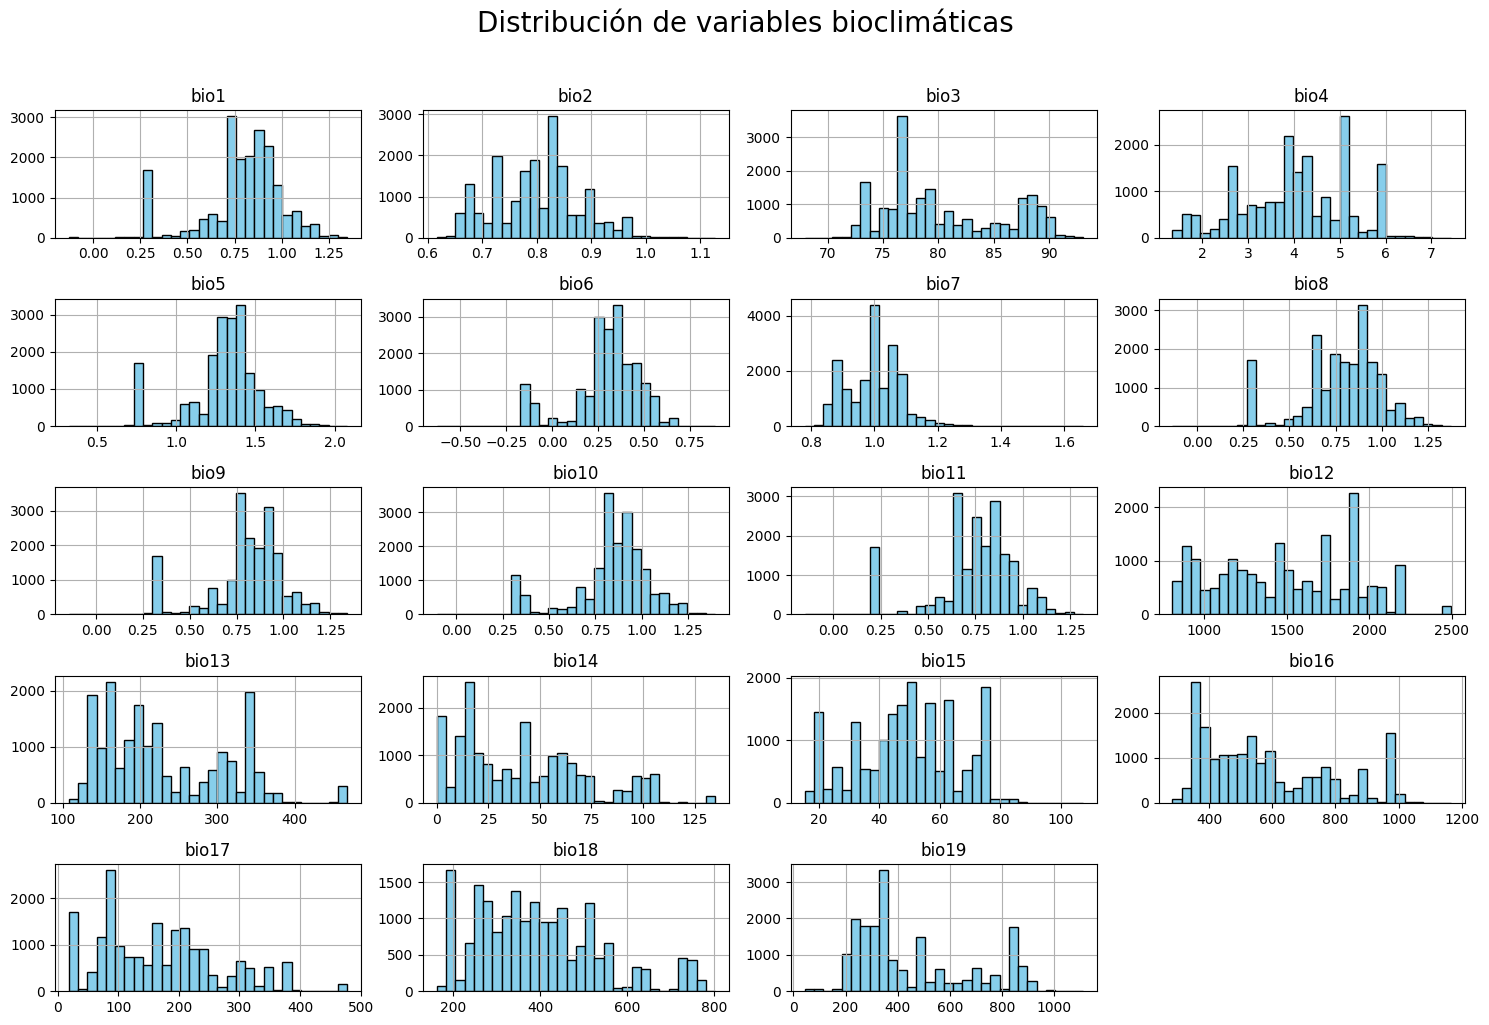

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 15))  # Cambia el tamaño del gráfico
biomodel[biomodel.columns[8:]].hist(bins=30, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle('Distribución de variables bioclimáticas', fontsize=20, y=1.02)  # Título general
plt.tight_layout()  # Ajusta automáticamente los subgráficos
plt.show()

## Matriz de correlación (heatmap)

In [95]:
# ---------- 2. Etiquetas descriptivas ----------
bio_labels = {
    "bio1": "Temp media anual",
    "bio2": "Rango diurno medio",
    "bio3": "Isotermalidad",
    "bio4": "Rango temp anual",
    "bio5": "Temp máx mes cálido",
    "bio6": "Temp mín mes frío",
    "bio7": "Amplitud térmica",
    "bio8": "Temp media trim húmedo",
    "bio9": "Temp media trim seco",
    "bio10": "Temp media trim cálido",
    "bio11": "Temp media trim frío",
    "bio12": "Precipitación anual",
    "bio13": "Prec. mes más húmedo",
    "bio14": "Prec. mes más seco",
    "bio15": "Estacionalidad prec.",
    "bio16": "Prec. trim más húmedo",
    "bio17": "Prec. trim más seco",
    "bio18": "Prec. trim más cálido",
    "bio19": "Prec. trim más frío"
}


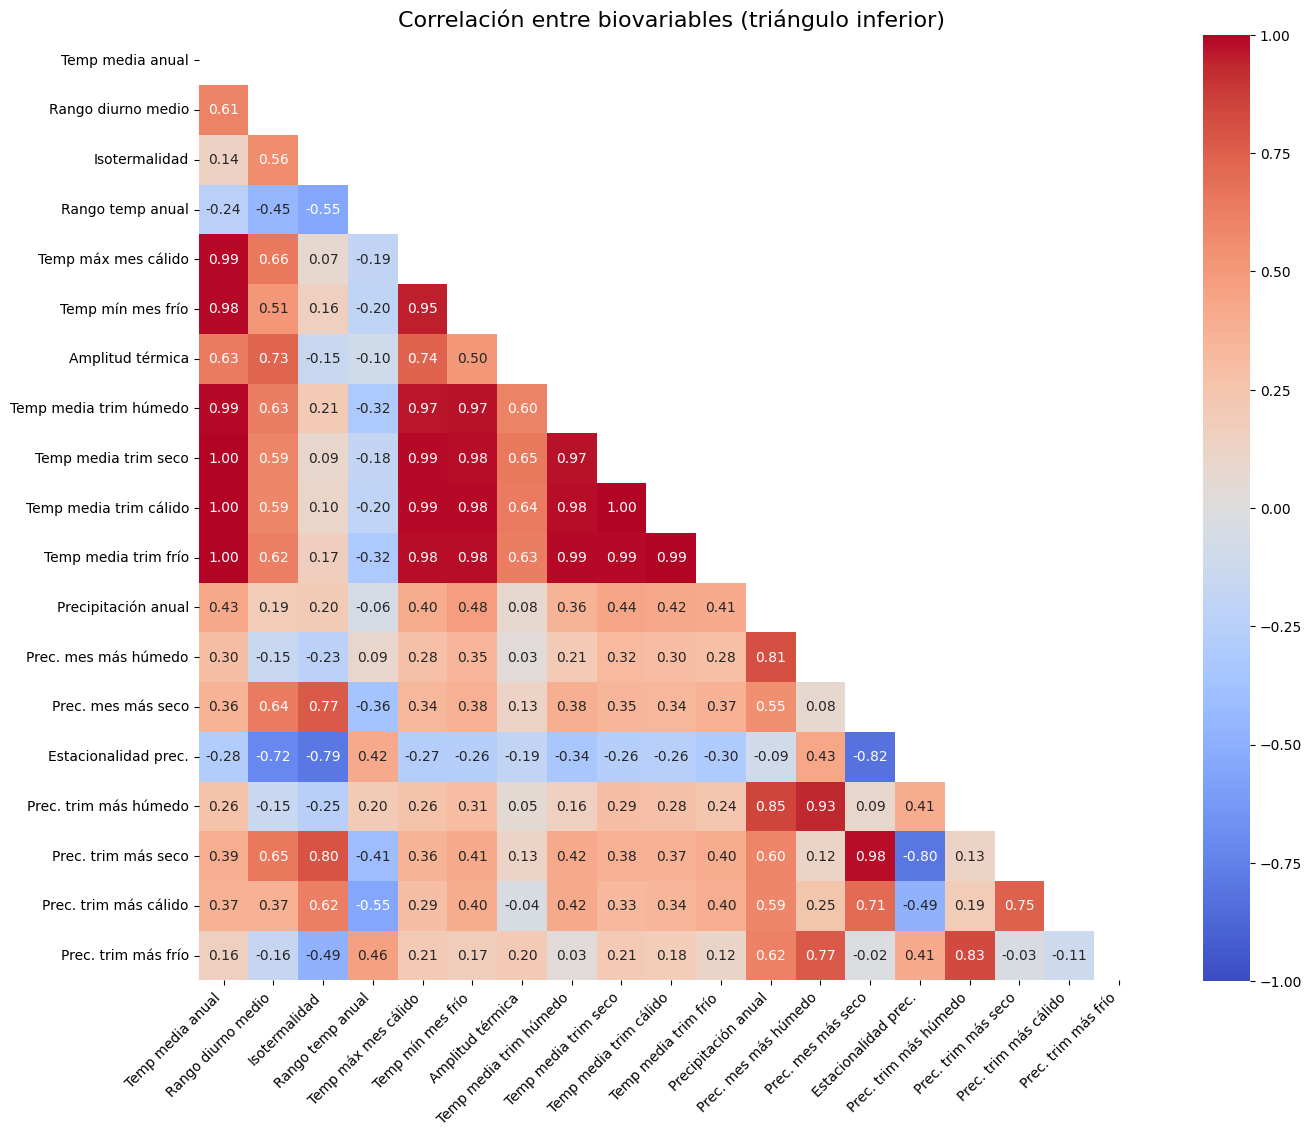

In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ---------- 3. Matriz de correlación ----------
corr = biomodel[biomodel.columns[8:]].corr()

# ---------- 4. Heatmap triangular inferior ----------
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(14, 12))
sns.heatmap(corr.rename(index=bio_labels, columns=bio_labels), 
            mask=mask, cmap='coolwarm', vmin=-1, vmax=1, 
            annot=True, fmt=".2f", square=True, cbar_kws={"shrink": 0.9})
plt.title("Correlación entre biovariables (triángulo inferior)", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

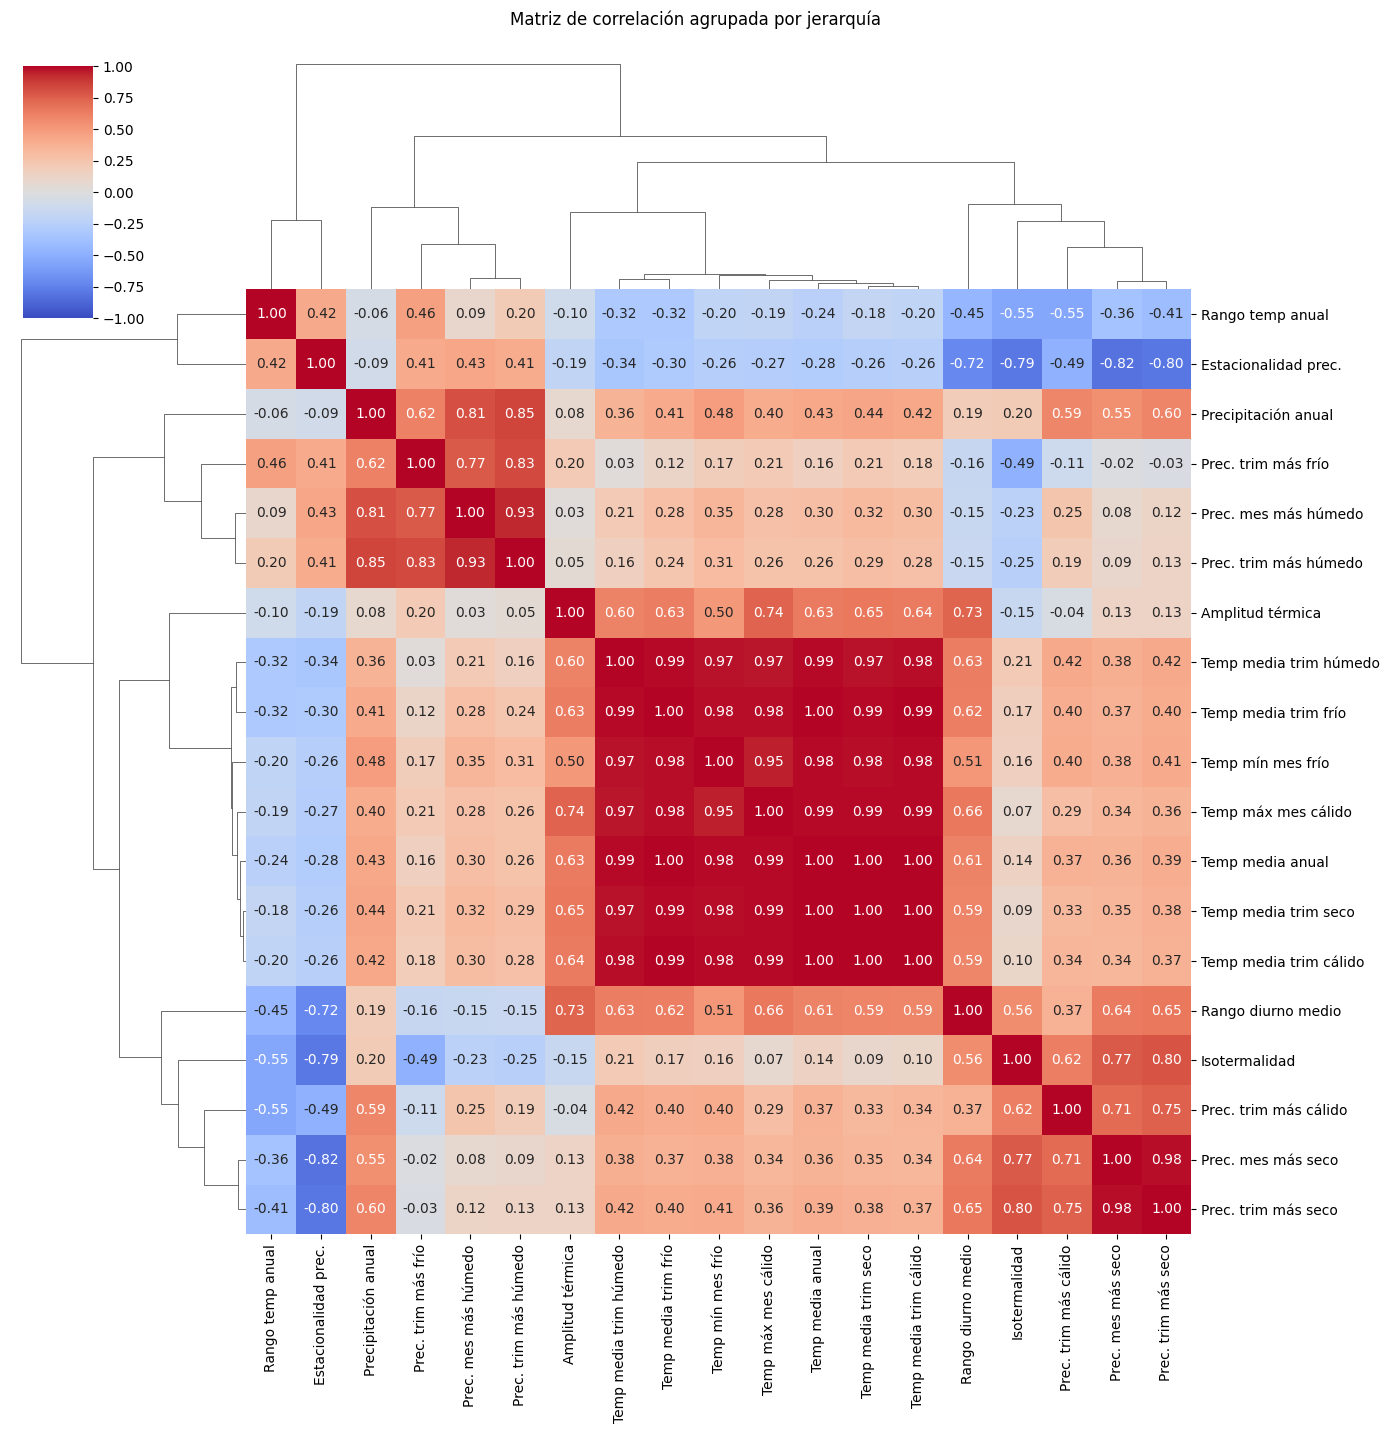

In [97]:
# ---------- 5. Clustermap (opcional) ----------
sns.clustermap(corr, cmap='coolwarm', vmin=-1, vmax=1,
               figsize=(14, 14), annot=True, fmt=".2f",
               row_cluster=True, col_cluster=True,
               xticklabels=[bio_labels[c] for c in corr.columns],
               yticklabels=[bio_labels[r] for r in corr.index])
plt.suptitle("Matriz de correlación agrupada por jerarquía", y=1.02)
plt.show()


In [98]:
# ---------- 6. Detección de colinealidad alta ----------
# Filtrar pares de variables con |r| > 0.8 y no repetidos
corr_unstacked = corr.abs().unstack().reset_index()
corr_unstacked.columns = ['var1', 'var2', 'correlation']
corr_filtered = corr_unstacked[(corr_unstacked['var1'] != corr_unstacked['var2']) &
                               (corr_unstacked['correlation'] > 0.8)]
# Eliminar duplicados tipo (bio01, bio02) y (bio02, bio01)
corr_filtered['pair'] = corr_filtered.apply(lambda row: tuple(sorted([row['var1'], row['var2']])), axis=1)
corr_filtered = corr_filtered.drop_duplicates('pair').drop(columns='pair')
print("📌 Pares de variables altamente correlacionadas (|r| > 0.8):")
print(corr_filtered.sort_values(by='correlation', ascending=False))


📌 Pares de variables altamente correlacionadas (|r| > 0.8):
      var1   var2  correlation
9     bio1  bio10     0.998925
161   bio9  bio10     0.997212
10    bio1  bio11     0.996803
8     bio1   bio9     0.995426
181  bio10  bio11     0.992699
143   bio8  bio11     0.991141
84    bio5   bio9     0.990111
85    bio5  bio10     0.988989
7     bio1   bio8     0.987990
4     bio1   bio5     0.987288
162   bio9  bio11     0.987173
5     bio1   bio6     0.984999
104   bio6  bio10     0.984640
142   bio8  bio10     0.983088
263  bio14  bio17     0.980137
86    bio5  bio11     0.980058
103   bio6   bio9     0.979769
105   bio6  bio11     0.978595
141   bio8   bio9     0.974874
102   bio6   bio8     0.971907
83    bio5   bio8     0.966035
81    bio5   bio6     0.952408
243  bio13  bio16     0.934279
224  bio12  bio16     0.850102
303  bio16  bio19     0.834727
261  bio14  bio15     0.820427
221  bio12  bio13     0.806164
282  bio15  bio17     0.804357


C:\Users\danie\AppData\Local\Temp\ipykernel_23848\1206233821.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corr_filtered['pair'] = corr_filtered.apply(lambda row: tuple(sorted([row['var1'], row['var2']])), axis=1)


In [99]:
corr_filtered

,var1,var2,correlation
4,bio1,bio5,0.987288
5,bio1,bio6,0.984999
7,bio1,bio8,0.987990
8,bio1,bio9,0.995426
9,bio1,bio10,0.998925
10,bio1,bio11,0.996803
81,bio5,bio6,0.952408
83,bio5,bio8,0.966035
84,bio5,bio9,0.990111
85,bio5,bio10,0.988989


In [100]:
corr_filtered['var1'].unique()

array(['bio1', 'bio5', 'bio6', 'bio8', 'bio9', 'bio10', 'bio12', 'bio13',
       'bio14', 'bio15', 'bio16'], dtype=object)

Otro criterio importante es qué tanta variabilidad presentan las variables. Mayor variabilidad puede ser mejor para el modelo, más capacidad de explicar la variación de los puntos.

In [101]:
var = biomodel[biomodel.columns[8:]].describe()
#var = var.loc[['std','mean']]
var

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
count,18960.000000,18960.000000,18960.000000,18960.000000,18960.000000,18960.000000,18960.000000,18960.000000,18960.000000,18960.000000,18960.000000,18960.000000,18960.000000,18960.000000,18960.000000,18960.000000,18960.000000,18960.000000,18960.000000
mean,0.794581,0.801216,80.350039,4.018161,1.297973,0.299933,0.998040,0.784508,0.802158,0.837921,0.743298,1492.888186,230.944462,41.587605,49.370256,578.094673,167.065401,394.732859,454.985021
std,0.209977,0.078952,5.545459,1.139760,0.235475,0.182718,0.082938,0.210375,0.205794,0.209088,0.216285,412.382670,79.197770,31.163135,16.390744,200.597837,97.490400,142.294710,222.386730
min,-0.129583,0.616667,67.921692,1.345588,0.320000,-0.630000,0.780000,-0.135000,-0.145000,-0.105000,-0.150000,808.000000,108.000000,0.000000,15.372871,284.000000,18.000000,163.000000,43.000000
25%,0.738333,0.730000,76.325760,3.222493,1.230000,0.240000,0.930000,0.665000,0.753333,0.776667,0.661667,1161.000000,162.000000,14.000000,38.216133,397.000000,88.000000,281.000000,283.000000
50%,0.828750,0.801667,78.763435,4.023370,1.340000,0.330000,1.000000,0.810000,0.831667,0.871667,0.771667,1462.000000,207.000000,38.000000,49.308792,525.000000,157.000000,377.000000,359.000000
75%,0.922917,0.843333,86.111107,5.017394,1.420000,0.410000,1.050000,0.915000,0.928333,0.970000,0.875000,1882.000000,304.000000,62.000000,62.276604,738.000000,226.000000,484.000000,605.000000
max,1.347500,1.127500,93.085106,7.425769,2.080000,0.890000,1.660000,1.376667,1.340000,1.396667,1.316667,2494.000000,468.000000,135.000000,107.247635,1166.000000,478.000000,802.000000,1110.000000


In [102]:
e = (var.loc['std'] / var.loc['mean']) * 100
e

bio1     26.426142
bio2      9.854073
bio3      6.901626
bio4     28.365222
bio5     18.141783
bio6     60.919465
bio7      8.310083
bio8     26.816218
bio9     25.654992
bio10    24.953204
bio11    29.098028
bio12    27.623145
bio13    34.292994
bio14    74.933710
bio15    33.199633
bio16    34.699824
bio17    58.354632
bio18    36.048357
bio19    48.877813
dtype: float64

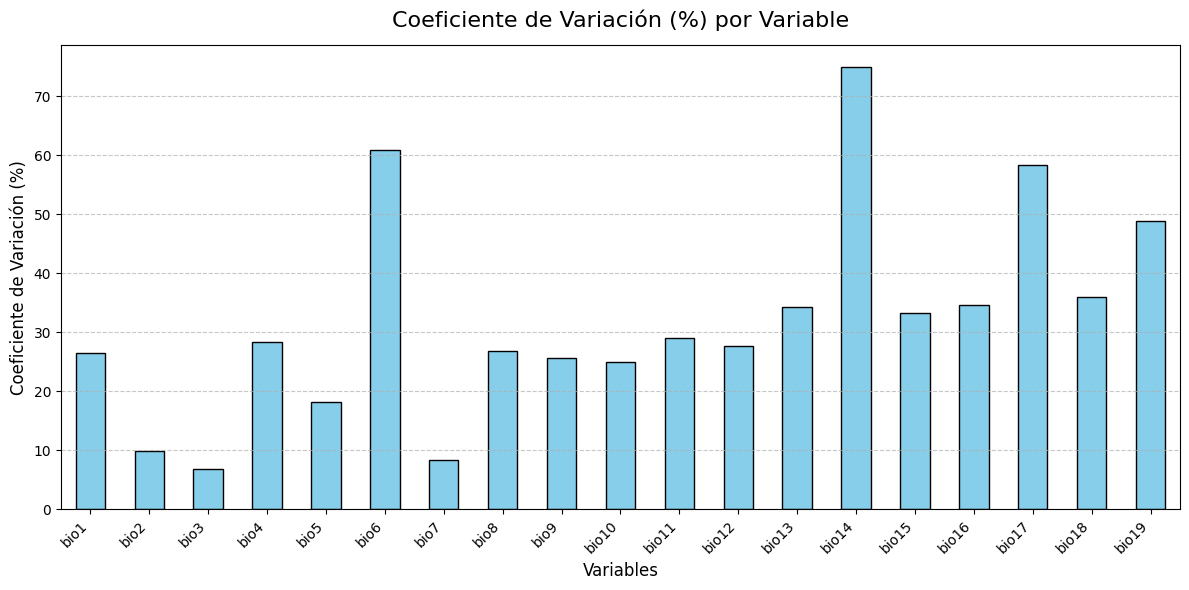

In [103]:
import matplotlib.pyplot as plt

# Graficar e como un gráfico de barras
e.plot(kind='bar', figsize=(12, 6), color='skyblue', edgecolor='black')
plt.title('Coeficiente de Variación (%) por Variable', fontsize=16, y=1.02)
plt.xlabel('Variables', fontsize=12, y=1.02)
plt.ylabel('Coeficiente de Variación (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotar etiquetas del eje x para mejor legibilidad
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### VIF (Variance Inflation Factor)

📌 ¿Qué es el VIF (Variance Inflation Factor)?  

👉 El Factor de Inflación de la Varianza (VIF) mide cuánto se “infla” la varianza de una variable explicativa debido a su colinealidad con las otras variables.

👉 Es un número que te dice:
“¿Esta variable aporta algo nuevo o es redundante?”

📌 ¿Por qué usarlo en WorldClim?  
Porque muchas biovariables están correlacionadas (como viste). Si usas varias variables correlacionadas en un modelo (por ejemplo, MaxEnt, GLM, RandomForest), puedes:

Sobreajustar

Inflar la varianza de los coeficientes

Interpretaciones erróneas

Por eso, se usa el VIF para filtrar las variables y quedarte con un subconjunto “limpio”

In [105]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calcular el Factor de Inflación de Varianza (VIF) para detectar multicolinealidad
# Solo las columnas de variables
X = biomodel[['bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 
        'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 
        'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19']]

# Agregar constante (requerido por statsmodels)
X = sm.add_constant(X)

# Calcular VIF para cada variable
vif_data = pd.DataFrame()
vif_data["variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                   for i in range(X.shape[1])]

# Mostrar resultado
print(vif_data)


   variable           VIF
0     const  1.083826e+05
1      bio1  1.743722e+04
2      bio2  1.015272e+03
3      bio3  5.105468e+02
4      bio4  5.064897e+01
5      bio5  6.928615e+13
6      bio6  4.150783e+13
7      bio7  8.561976e+12
8      bio8  1.849558e+02
9      bio9  3.461664e+02
10    bio10  8.818993e+03
11    bio11  5.482254e+03
12    bio12  7.738632e+01
13    bio13  2.435574e+01
14    bio14  3.994066e+01
15    bio15  3.300269e+01
16    bio16  6.254806e+01
17    bio17  6.162563e+01
18    bio18  9.952684e+00
19    bio19  1.306225e+01


In [ ]:
vif_data.sort_values(by='VIF', ascending=False) # Vemos que hay unas variables muy voladas

,variable,VIF
5,bio5,6.928615e+13
6,bio6,4.150783e+13
7,bio7,8.561976e+12
0,const,1.083826e+05
1,bio1,1.743722e+04
10,bio10,8.818993e+03
11,bio11,5.482254e+03
2,bio2,1.015272e+03
3,bio3,5.105468e+02
9,bio9,3.461664e+02


Calculamos y evaluamos de nuevo pero ahora con un set reducido de variables

In [115]:
# Calcular el Factor de Inflación de Varianza (VIF) para detectar multicolinealidad
# Solo las columnas de variables
X = biomodel[['bio1','bio3','bio4','bio7','bio12','bio15']]

# Agregar constante (requerido por statsmodels)
X = sm.add_constant(X)

# Calcular VIF para cada variable
vif_data = pd.DataFrame()
vif_data["variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                   for i in range(X.shape[1])]

# Mostrar resultado
print(vif_data)

  variable          VIF
0    const  2671.058495
1     bio1     2.356323
2     bio3     5.406066
3     bio4     1.634617
4     bio7     2.490141
5    bio12     1.428459
6    bio15     4.159498


In [23]:
biomodel.columns

Index(['countryCode', 'elevation_DEM', 'genus', 'lat', 'lon', 'species',
       '.geo', 'geometry', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6',
       'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14',
       'bio15', 'bio16', 'bio17', 'bio18', 'bio19'],
      dtype='object')

In [24]:
# Por ultimo, separamos y exportamos el dataframe solo con esas columnas
final = biomodel[['countryCode','elevation_DEM','genus','lat', 'lon', 'species','bio1','bio3','bio4','bio7','bio12','bio15','.geo', 'geometry']]
final.to_csv('../data/WorldClim_v2.csv')

## Modelo Regresión Logistica

### Selección de las variables

Proponemos las siguientes variables a partir de la importancia y de los análisis de correlación y redundancia

| Variable | Significado                        | Justificación                   |
| -------- | ---------------------------------- | ------------------------------- |
| `bio01`  | Temperatura media anual            | General, robusta                |
| `bio03`  | Isotermalidad                      | Captura variabilidad térmica    |
| `bio04`  | Rango de temperatura anual         | Complementa `bio01`             |
| `bio07`  | Amplitud térmica anual             | Importante en zonas montañosas  |
| `bio12`  | Precipitación anual                | Indicador hídrico clave         |
| `bio15`  | Estacionalidad de la precipitación | Representa variabilidad hídrica |


In [60]:
#subset = ["bio01", "bio03", "bio04", "bio07", "bio12", "bio15"]
# Prueba con menos variables
subset = ["bio10"]

In [61]:
# 
# Seleccionar las columnas del subset y la columna 'y'
biomodel_subset = biomodel[subset + ['y']].copy()

# Mostrar información del nuevo DataFrame
print(biomodel_subset.info())
biomodel_subset.columns

<class 'pandas.core.frame.DataFrame'>
Index: 39538 entries, 3 to 41695
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   bio10   39538 non-null  float64
 1   y       39538 non-null  int64  
dtypes: float64(1), int64(1)
memory usage: 926.7 KB
None


Index(['bio10', 'y'], dtype='object')

In [62]:
import statsmodels.api as sm

# Agregar constante
X = sm.add_constant(biomodel_subset[subset])  # añade la constante (intercepto)
y = biomodel_subset['y']

# Ajuste del modelo
modelo = sm.Logit(y, X).fit()

print(modelo.summary())

Optimization terminated successfully.
         Current function value: 0.205130
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                39538
Model:                          Logit   Df Residuals:                    39536
Method:                           MLE   Df Model:                            1
Date:               mar, 27 may. 2025   Pseudo R-squ.:                  0.7040
Time:                        15:44:39   Log-Likelihood:                -8110.4
converged:                       True   LL-Null:                       -27398.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.8591      0.089     88.000      0.000       7.684       8.034
bio10         -0.6355      0.

Optimization terminated successfully.
         Current function value: 0.205130
         Iterations 9

📊 Resumen del modelo:
                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: y                Pseudo R-squared: 0.704     
Date:               2025-05-27 15:44 AIC:              16224.8989
No. Observations:   39538            BIC:              16242.0690
Df Model:           1                Log-Likelihood:   -8110.4   
Df Residuals:       39536            LL-Null:          -27398.   
Converged:          1.0000           LLR p-value:      0.0000    
No. Iterations:     9.0000           Scale:            1.0000    
-------------------------------------------------------------------
          Coef.    Std.Err.      z       P>|z|     [0.025    0.975]
-------------------------------------------------------------------
const    -1.5305     0.0391   -39.1538   0.0000   -1.6072   -1.4539
bio10    -5.2152     0.0668   -78.0

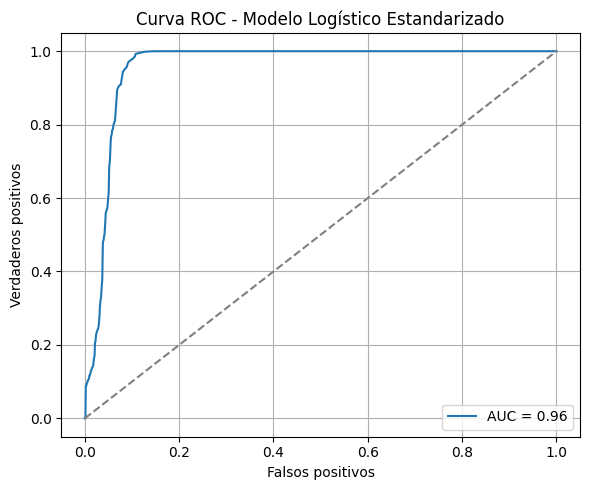

In [63]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Variables predictoras y respuesta
X_orig = biomodel_subset[subset]
y = biomodel_subset['y']

# 2. Estandarizar las variables
scaler = StandardScaler()
X_scaled_np = scaler.fit_transform(X_orig)

# 3. Convertir a DataFrame y conservar nombres de columnas
X_scaled = pd.DataFrame(X_scaled_np, columns=subset, index=X_orig.index)

# 4. Agregar constante para el intercepto
X_scaled = sm.add_constant(X_scaled)

# 5. Ajustar modelo logístico
modelo = sm.Logit(y, X_scaled).fit()

# 6. Resumen del modelo
print("\n📊 Resumen del modelo:")
print(modelo.summary2())

# 7. Odds Ratios (OR)
resumen = modelo.summary2().tables[1]
resumen['OR'] = np.exp(resumen['Coef.'])
print("\n🧠 Coeficientes estandarizados y Odds Ratios:")
print(resumen[['Coef.', 'Std.Err.', 'P>|z|', 'OR']].round(4))

# 8. Pseudo R² de McFadden
print(f"\n📈 McFadden R²: {modelo.prsquared:.4f}")

# 9. Curva ROC
y_prob = modelo.predict(X_scaled)
fpr, tpr, _ = roc_curve(y, y_prob)
auc = roc_auc_score(y, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel('Falsos positivos')
plt.ylabel('Verdaderos positivos')
plt.title('Curva ROC - Modelo Logístico Estandarizado')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Modelo con Sklearn: Validación cruzada

In [45]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# Crear el pipeline: primero escala, luego ajusta modelo
pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42, class_weight='balanced')
)

# Validación cruzada usando AUC como métrica
scores = cross_val_score(
    pipeline,
    biomodel_subset[subset],   # X
    biomodel_subset['y'],      # y
    cv=5,
    scoring='roc_auc'
)

# Mostrar resultados
print("AUC promedio (CV=5):", scores.mean())
print("AUCs por fold:", scores)

AUC promedio (CV=5): 0.9681127969125735
AUCs por fold: [0.97168686 0.96176638 0.97520642 0.97452732 0.957377  ]


### Modelo con Sklearn: Curva ROC - Entrenamiento y testeo

Matriz de confusión:
[[5276  540]
 [  76 5970]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      0.91      0.94      5816
           1       0.92      0.99      0.95      6046

    accuracy                           0.95     11862
   macro avg       0.95      0.95      0.95     11862
weighted avg       0.95      0.95      0.95     11862



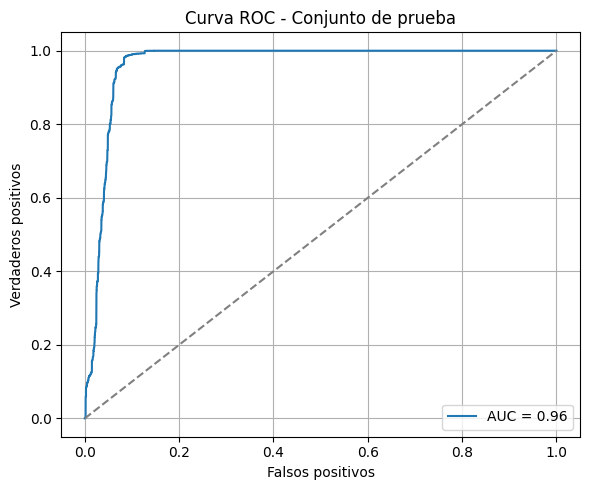

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    biomodel_subset[subset],
    biomodel_subset['y'],
    test_size=0.3,
    random_state=42,
    stratify=biomodel_subset['y']
)

# Pipeline con estandarización y modelo logístico balanceado
pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42, class_weight='balanced')
)

# Entrenar el modelo
pipeline.fit(X_train, y_train)

# Obtener probabilidades en test
y_prob = pipeline.predict_proba(X_test)[:, 1]  # probabilidad de clase 1
y_pred = pipeline.predict(X_test)  # clasificación binaria

# Matriz de confusión con conjunto de prueba
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

# Reporte de métricas
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

# Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel('Falsos positivos')
plt.ylabel('Verdaderos positivos')
plt.title('Curva ROC - Conjunto de prueba')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Comparando todas las variables dentro del modelo

In [56]:
All = ['bio01', 'bio02', 'bio04', 'bio05', 'bio06', 'bio07', 'bio08', 'bio09', 
 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19']

In [57]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import pandas as pd
import numpy as np

# 1. Variables predictoras
X = biomodel[All]
y = biomodel['y']

# 2. Estandarizar
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=subset, index=X.index)

# 3. Agregar constante
X_scaled = sm.add_constant(X_scaled)

# 4. Ajustar modelo
modelo = sm.Logit(y, X_scaled).fit()

# 5. Obtener coeficientes y Odds Ratios
resumen = modelo.summary2().tables[1]
resumen['OR'] = np.exp(resumen['Coef.'])

# 6. Ordenar por magnitud del coeficiente
print("\nVariables más influyentes (en escala estandarizada):")
resumen[['Coef.', 'P>|z|', 'OR']].sort_values(by='Coef.', key=np.abs, ascending=False)


         Current function value: 0.149876
         Iterations: 35

Variables más influyentes (en escala estandarizada):


c:\Users\danie\miniconda3\envs\GeoSpatial\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Coef.,P>|z|,OR
bio10,61.650345,2.018203e-51,5.948459e+26
bio11,-54.369023,3.005112e-30,2.442493e-24
bio09,17.346791,1.235563e-43,3.416768e+07
bio06,-10.219259,9.999995e-01,3.646130e-05
bio05,-9.462982,9.999996e-01,7.767460e-05
bio16,-7.385232,1.768394e-35,6.203468e-04
bio08,-6.736466,8.515651e-10,1.186834e-03
bio18,3.532583,1.437021e-103,3.421223e+01
bio01,-2.746071,5.257033e-01,6.417950e-02
const,-2.352080,2.253733e-220,9.517099e-02
